# 🇮🇳 AI-Driven Citizen Grievance & Sentiment Analysis System

## Week 1: Data Ingestion & Exploratory Data Analysis (EDA)

### Objective
The goal of this notebook is to:
- Load and understand the grievance dataset
- Perform exploratory data analysis (EDA)
- Identify patterns in citizen complaints
- Visualize common issues using word clouds and n-grams

This analysis will help in building robust NLP models for:
- Department classification
- Sentiment and urgency detection

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/interim/cleaned_data.csv")

df.head()

,text,department,sentiment,clean_text,processed_text
0,"No water supply in our area for last 3 days, p...",Water,Urgent,no water supply in our area for last days plea...,water supply area last day resolve urgently
1,Water is coming very dirty and smells bad,Water,Negative,water is coming very dirty and smells bad,water come dirty smell bad
2,Low water pressure in the morning hours,Water,Negative,low water pressure in the morning hours,low water pressure morning hour
3,Thank you for restoring water supply quickly,Water,Positive,thank you for restoring water supply quickly,restore water supply quickly
4,Pipeline leakage near main road causing wastage,Water,Urgent,pipeline leakage near main road causing wastage,pipeline leakage near main road cause wastage


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            41 non-null     object
 1   department      41 non-null     object
 2   sentiment       41 non-null     object
 3   clean_text      41 non-null     object
 4   processed_text  41 non-null     object
dtypes: object(5)
memory usage: 1.7+ KB


In [4]:
df.describe()

,text,department,sentiment,clean_text,processed_text
count,41,41,41,41,41
unique,41,6,4,41,41
top,"No water supply in our area for last 3 days, p...",Water,Negative,no water supply in our area for last days plea...,water supply area last day resolve urgently
freq,1,7,21,1,1


In [5]:
df.isnull().sum()

text              0
department        0
sentiment         0
clean_text        0
processed_text    0
dtype: int64

In [6]:
for i in range(5):
    print("Original:", df["text"].iloc[i])
    print("Cleaned :", df["clean_text"].iloc[i])
    print("Processed:", df["processed_text"].iloc[i])
    print("-" * 80)

Original: No water supply in our area for last 3 days, please resolve urgently
Cleaned : no water supply in our area for last days please resolve urgently
Processed: water supply area last day resolve urgently
--------------------------------------------------------------------------------
Original: Water is coming very dirty and smells bad
Cleaned : water is coming very dirty and smells bad
Processed: water come dirty smell bad
--------------------------------------------------------------------------------
Original: Low water pressure in the morning hours
Cleaned : low water pressure in the morning hours
Processed: low water pressure morning hour
--------------------------------------------------------------------------------
Original: Thank you for restoring water supply quickly
Cleaned : thank you for restoring water supply quickly
Processed: restore water supply quickly
--------------------------------------------------------------------------------
Original: Pipeline leakage near

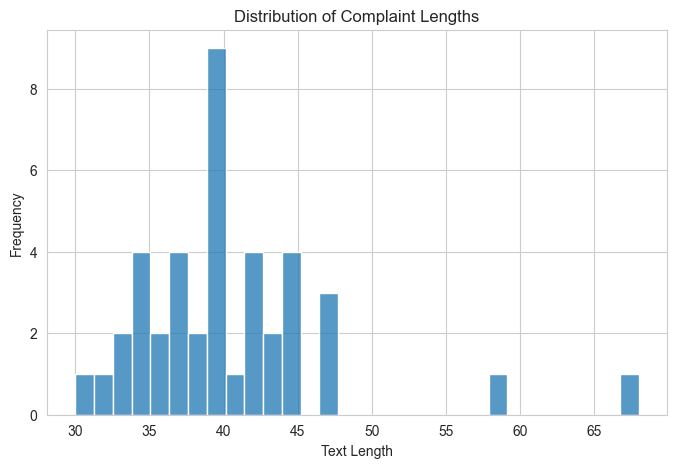

In [7]:
df["text_length"] = df["text"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=30)
plt.title("Distribution of Complaint Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

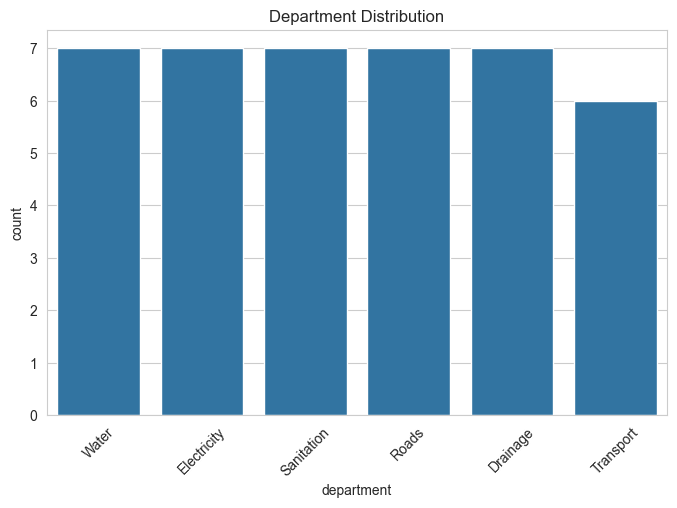

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.title("Department Distribution")
plt.xticks(rotation=45)
plt.show()

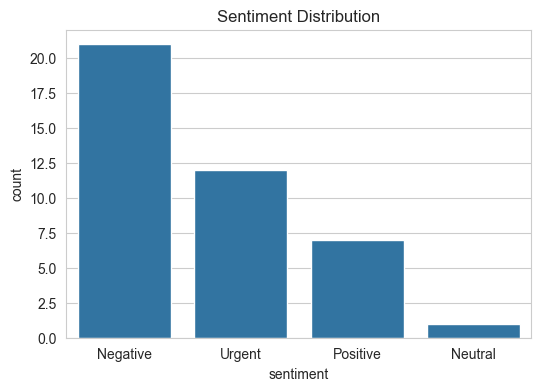

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment", order=df["sentiment"].value_counts().index)
plt.title("Sentiment Distribution")
plt.show()

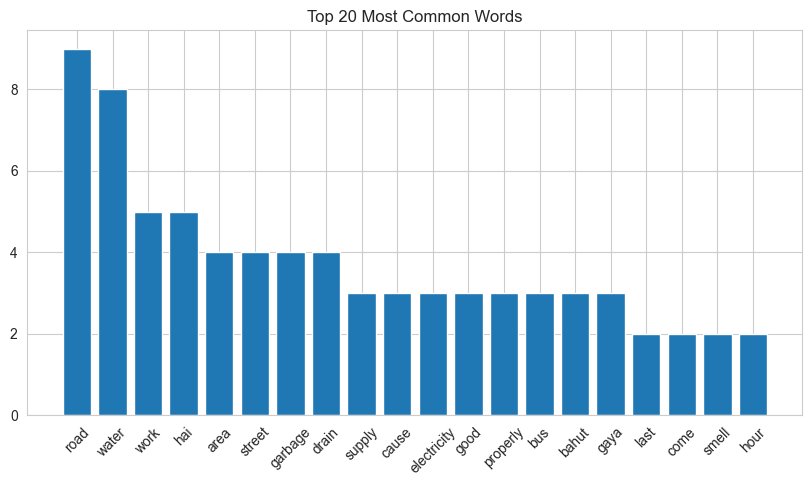

In [10]:
all_words = " ".join(df["processed_text"])

word_counts = Counter(all_words.split())

common_words = word_counts.most_common(20)

words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words")
plt.show()

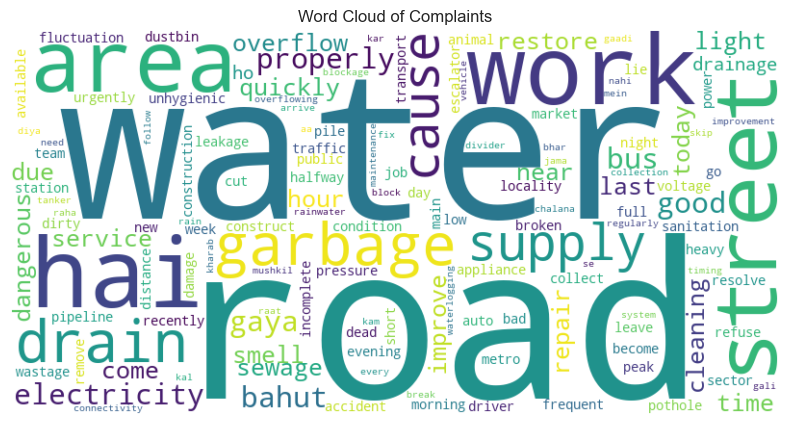

In [11]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Complaints")
plt.show()

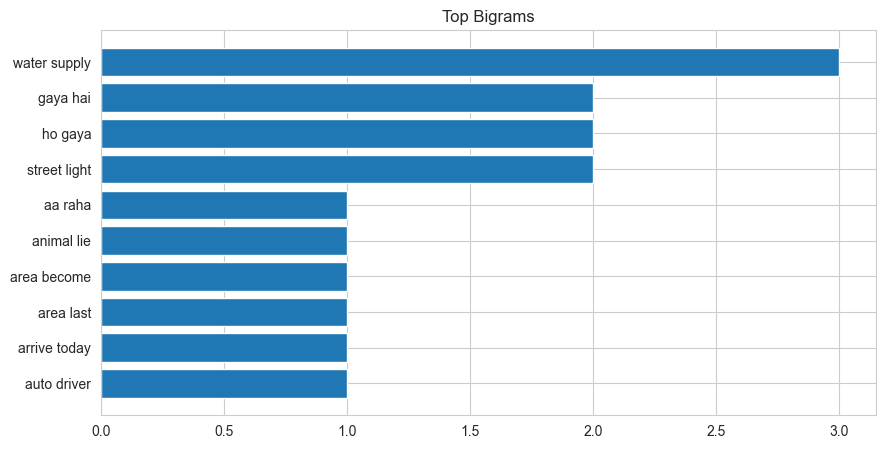

In [12]:
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(df["processed_text"])

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

bigram_freq = dict(zip(bigrams, bigram_counts))
top_bigrams = sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)[:10]

bigrams, counts = zip(*top_bigrams)

plt.figure(figsize=(10,5))
plt.barh(bigrams, counts)
plt.title("Top Bigrams")
plt.gca().invert_yaxis()
plt.show()

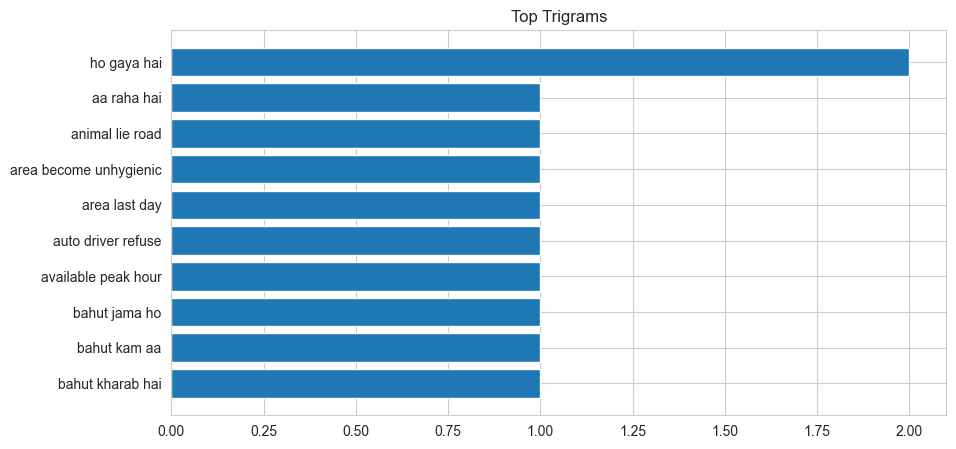

In [13]:
vectorizer = CountVectorizer(ngram_range=(3,3))
X = vectorizer.fit_transform(df["processed_text"])

trigram_counts = X.sum(axis=0).A1
trigrams = vectorizer.get_feature_names_out()

trigram_freq = dict(zip(trigrams, trigram_counts))
top_trigrams = sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True)[:10]

trigrams, counts = zip(*top_trigrams)

plt.figure(figsize=(10,5))
plt.barh(trigrams, counts)
plt.title("Top Trigrams")
plt.gca().invert_yaxis()
plt.show()

## Key Insights

1. **Most Frequent Issues**
   - Words like "water", "road", "garbage", and "electricity" dominate complaints.
   - Indicates core civic infrastructure problems.

2. **Department Trends**
   - Certain departments receive significantly more complaints.
   - Helps prioritize resource allocation.

3. **Sentiment Observations**
   - Majority of complaints fall under "Negative" and "Urgent".
   - Highlights dissatisfaction and need for faster response systems.

4. **Common Complaint Patterns**
   - Bigrams like "water supply", "power cut", "garbage collection"
   - Trigrams like "no water supply", "road repair work"

5. **Language Patterns**
   - Presence of Hinglish indicates need for robust preprocessing.